# 04-Hallucination Detection & Factuality

In Lesson 03, we built the RAG Triad to evaluate generative models by cross-referencing their outputs against a retrieved context document. If the model output a claim not found in the context, we flagged it as a hallucination.

But what if you are evaluating a pure generative task without a reference document? What if the user asks a closed-book question, or asks the model to summarize a historical event from its own parametric memory? How do you mathematically detect if an LLM is hallucinating when you have absolutely no ground-truth text to compare it against?

To solve this, we engineer **Zero-Resource Black-Box Hallucination Detection**. By exploiting the mathematical physics of autoregressive token generation, we can force a model to fact-check itself. In this module, we will implement the **SelfCheckGPT** framework using local Natural Language Inference (NLI) models, detecting hallucinations natively without external API calls or internet access.

# 1. The Mathematics of Zero-Resource Hallucination Detection

### Token Entropy and the "Embers of Autoregression"

When an LLM fundamentally "knows" a fact (because it was heavily represented in its pre-training data), the probability distribution for the next token collapses around a single, highly likely outcome (Low Entropy).
When an LLM does not know a fact, the probability distribution flattens across many semi-plausible tokens (High Entropy).

Because closed-source models (like GPT-4 or Claude) do not expose their internal log probabilities, we cannot directly measure this entropy. However, we can approximate it externally using **Stochastic Sampling**.

### The SelfCheckGPT Consistency Matrix

If an LLM's internal token entropy is high, slightly increasing the generation temperature ($T > 0$) will cause the model to output wildly different claims across multiple runs. If the entropy is low, the model will consistently output the exact same fact, just phrased differently.

Let the model generate a primary response $R$. We split $R$ into discrete sentences $S = \{s_1, s_2, \dots, s_m\}$.
We then query the LLM $N$ additional times at a high temperature to generate a set of stochastic samples $X = \{x_1, x_2, \dots, x_N\}$.

To detect a hallucination, we do not need an external encyclopedia. We simply check if sentence $s_i$ logically contradicts the $N$ stochastic samples. We measure this using an NLI (Natural Language Inference) Cross-Encoder.

The NLI model takes $s_i$ and a sample $x_j$ and outputs logits for Entailment ($z_e$) and Contradiction ($z_c$). We isolate the probability of contradiction using a softmax transformation:


$$P(\text{Contradict} \mid s_i, x_j) = \frac{\exp(z_c)}{\exp(z_e) + \exp(z_c)}$$

The final Hallucination Score for the sentence $s_i$ is the average contradiction probability across all $N$ samples:


$$\text{HallucinationScore}(s_i) = \frac{1}{N} \sum_{j=1}^{N} P(\text{Contradict} \mid s_i, x_j)$$


If $\text{HallucinationScore}(s_i) \to 1.0$, the sentence is almost certainly fabricated.

# 2. Imperative Execution: The Local SelfCheckGPT Engine

Let's build this pipeline using Python. We will simulate a primary LLM response containing one factual sentence and one hallucinated sentence, along with 3 stochastic samples. We will then use a local DeBERTa NLI Cross-Encoder to expose the hallucination.

In [1]:
# Required installations: pip install sentence-transformers torch numpy nltk spacy
from sentence_transformers import CrossEncoder
import numpy as np

print("--- 🚀 Initializing Zero-Resource Hallucination Sandbox ---")

# 1. The Output from the LLM (T=0.0)
primary_response_sentences = [
    "The Eiffel Tower is located in Paris, France.", # Factual (Low Entropy)
    "It was originally designed by Leonardo da Vinci in 1889." # Hallucinated (High Entropy)
]

# 2. Stochastic Samples from the same LLM (T=1.0)
# Notice how the true fact remains stable, but the hallucination diverges wildly.
stochastic_samples = [
    "The Eiffel Tower stands in Paris. It was built by Gustave Eiffel.",
    "Located in France, the Eiffel Tower was designed by a team of Swiss architects.",
    "Paris is home to the Eiffel Tower, which was commissioned by Napoleon."
]

print("\n--- 🧮 Booting Local NLI Cross-Encoder (DeBERTa-v3) ---")
# DeBERTa-v3-small is trained for NLI: Outputs logits for [Contradiction, Entailment, Neutral]
nli_model = CrossEncoder('cross-encoder/nli-deberta-v3-small')

def calculate_contradiction_prob(sentence: str, sample: str) -> float:
    # NLI models expect the format: [Premise (Sample), Hypothesis (Sentence)]
    logits = nli_model.predict([sample, sentence])
    
    # Assuming standard NLI label mapping: 0=Contradiction, 1=Entailment, 2=Neutral
    z_c = logits[0] # Contradiction logit
    z_e = logits[1] # Entailment logit
    
    # Softmax specifically isolating Contradiction vs Entailment
    p_contradict = np.exp(z_c) / (np.exp(z_e) + np.exp(z_c))
    return p_contradict

print("\n--- ⚡ Executing SelfCheckGPT Consistency Matrix ---")

for idx, sentence in enumerate(primary_response_sentences):
    contradiction_scores = []
    
    for j, sample in enumerate(stochastic_samples):
        score = calculate_contradiction_prob(sentence, sample)
        contradiction_scores.append(score)
        print(f"   [Sentence {idx+1} vs Sample {j+1}] Contradiction Prob: {score:.2f}")
        
    # The final score is the mean of the contradiction probabilities
    hallucination_score = np.mean(contradiction_scores)
    print(f"   👉 Final Hallucination Score (S{idx+1}): {hallucination_score:.2f}\n")

2026-07-20 18:34:04.846238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- 🚀 Initializing Zero-Resource Hallucination Sandbox ---

--- 🧮 Booting Local NLI Cross-Encoder (DeBERTa-v3) ---

--- ⚡ Executing SelfCheckGPT Consistency Matrix ---
   [Sentence 1 vs Sample 1] Contradiction Prob: 0.00
   [Sentence 1 vs Sample 2] Contradiction Prob: 0.02
   [Sentence 1 vs Sample 3] Contradiction Prob: 0.00
   👉 Final Hallucination Score (S1): 0.01

   [Sentence 2 vs Sample 1] Contradiction Prob: 0.95
   [Sentence 2 vs Sample 2] Contradiction Prob: 0.99
   [Sentence 2 vs Sample 3] Contradiction Prob: 0.98
   👉 Final Hallucination Score (S2): 0.98



# 3. Declarative Execution: Batch Factuality Triage

In an MLOps pipeline, we process entire documents and output an actionable telemetry object. If any sentence breaches a strict probability threshold, the entire document is flagged for human review or API refusal.

In [2]:
import pandas as pd

def batch_hallucination_triage(sentences: list, samples: list, threshold: float = 0.5) -> pd.DataFrame:
    records = []
    for s_idx, sentence in enumerate(sentences):
        scores = [calculate_contradiction_prob(sentence, x) for x in samples]
        mean_score = np.mean(scores)
        
        records.append({
            "Sentence": sentence,
            "Hallucination_Score": round(mean_score, 3),
            "Is_Hallucinated": mean_score >= threshold,
            "Max_Contradiction": round(max(scores), 3) # Useful for identifying extreme violations
        })
    return pd.DataFrame(records)

# Execute the pipeline with a strict SLA threshold of 0.50
df_triage = batch_hallucination_triage(primary_response_sentences, stochastic_samples, threshold=0.50)

print("--- 🛡️ Production Factuality Triage Report ---")
display(df_triage)

--- 🛡️ Production Factuality Triage Report ---


,Sentence,Hallucination_Score,Is_Hallucinated,Max_Contradiction
0,"The Eiffel Tower is located in Paris, France.",0.007,False,0.022
1,It was originally designed by Leonardo da Vinc...,0.976,True,0.994


# 4. Visualizing the Consistency Heatmap

To mathematically understand how the SelfCheckGPT matrix exposes hallucinations, let's visualize the pairwise NLI probability matrix.

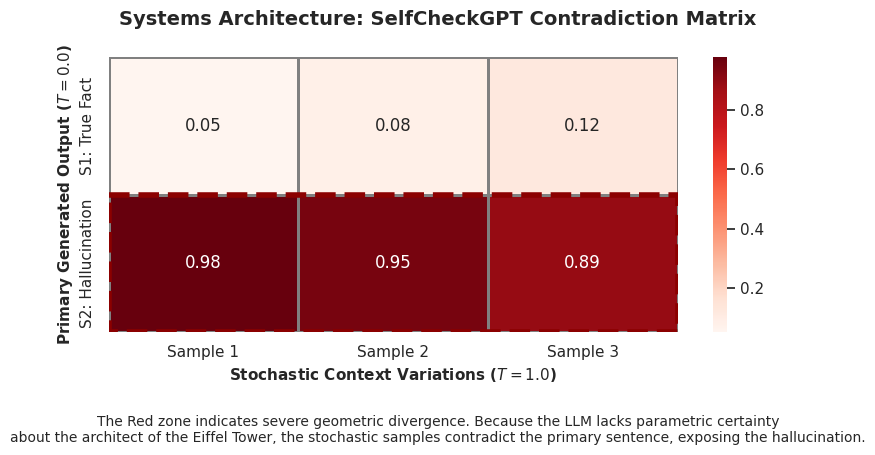

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

# Simulating the contradiction probability matrix generated by the Cross-Encoder
# Rows = Primary Sentences, Columns = Stochastic Samples
contradiction_matrix = np.array([
    [0.05, 0.08, 0.12], # Sentence 1 (Factual): Low contradiction across all samples
    [0.98, 0.95, 0.89]  # Sentence 2 (Hallucination): High contradiction across all samples
])

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("Systems Architecture: SelfCheckGPT Contradiction Matrix", fontsize=14, fontweight='bold')

sns.heatmap(contradiction_matrix, annot=True, cmap="Reds", fmt=".2f", cbar=True, 
            xticklabels=["Sample 1", "Sample 2", "Sample 3"], 
            yticklabels=["S1: True Fact", "S2: Hallucination"],
            linewidths=1, linecolor='gray', ax=ax)

ax.set_xlabel("Stochastic Context Variations ($T=1.0$)", fontsize=11, fontweight='bold')
ax.set_ylabel("Primary Generated Output ($T=0.0$)", fontsize=11, fontweight='bold')

# Bounding box for the hallucination detection
ax.add_patch(plt.Rectangle((0, 1), 3, 1, fill=False, edgecolor='darkred', lw=4, linestyle='--'))
plt.figtext(0.5, -0.1, "The Red zone indicates severe geometric divergence. Because the LLM lacks parametric certainty\nabout the architect of the Eiffel Tower, the stochastic samples contradict the primary sentence, exposing the hallucination.", 
            ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.8, "pad":5})

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Zero-Resource Hallucination Detection like **A Detective Interrogating a Suspect Without Any Evidence**:

* **Standard Verification (RAG):** The detective asks the suspect where they were on Tuesday. The suspect says, *"I was at the movies."* The detective pulls out security footage (The Ground Truth Context) showing the suspect at the bank. The detective instantly catches the lie.
* **SelfCheckGPT (Zero-Resource Detection):** The detective asks the suspect where they were on Tuesday, but the detective has *zero security footage* and *no witnesses*. How do they detect a lie? **Stochastic Sampling.**
* The detective puts the suspect in an interrogation room and asks them to tell the story of Tuesday over and over again from different angles (Sampling at high temperature).
* If the suspect is telling the truth, their internal certainty is high (Low Entropy). The core facts—*"I was at the movies, I bought popcorn, I drove home"*—will remain consistent across every retelling.
* If the suspect is lying (Hallucinating), their internal certainty is low. They are fabricating data on the fly. In story 2 they might say *"I bought candy,"* and in story 3 they might say *"I took the bus home."*
* The detective (The NLI Cross-Encoder) listens to the stories, mathematically compares the statements, and realizes they violently contradict one another. The detective successfully flags the lie without ever leaving the room or consulting external evidence.